In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
from models.qlearning import QLearningAgent

In [10]:
class SARSA:
    def __init__(self, grid_w = 12, grid_h = 4 ,start = [3,0], end = [3,11], epsilon = 0.1, gamma = 1, alpha = 0.5):
        self.start = start
        self.end = end
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha

        self.q_values_runs = np.zeros((4,12,4)) 

        self.actions = [[-1, 0], [1,0], [0, -1], [0, 1]]


        self.grid_w = grid_w
        self.grid_h = grid_h

        self.gridworld = np.zeros((grid_h,grid_w))

        for h in range(self.grid_h):
            for w in range(self. grid_w):
                if(h == 3) and (w == 0 or w ==11):
                    self.gridworld[h][w] = 0
                elif h != 3 and (w != 0 or w != 11):
                    self.gridworld[h][w] = -1
                else:
                    self.gridworld[h][w] = -100

        self.reward_sum_per_episode = None




    def __epsilon_greedy_choice(self, state, epsilon_var, q_values):
        explore = np.random.uniform(0,1)
        if(explore <= epsilon_var):
            action_index = np.random.choice([0 ,1 ,2 ,3])
            action = self.actions[action_index]
        else:
            max_indexes = np.where(q_values[state[0]][state[1]] == np.max(q_values[state[0]][state[1]]))[0]
    
            action_idx = np.random.choice(max_indexes)
            action = self.actions[action_idx]
        return action


    def __out_of_bounds(self, state):
        
        if state[0] < 0 or state[0] > 3 or state[1] < 0 or state[1] > 11:
            return True
        return False  
        

    def __step(self, state, action):
        
        vertical, horizontal = action
       
        if self.__out_of_bounds([state[0] + vertical, state[1] + horizontal]):
            reward = -1
            return state, reward

        next_state = [state[0] + vertical, state[1] + horizontal]
        reward = self.gridworld[next_state[0]][next_state[1]]

        return (next_state, reward)

    def __episode(self, q_values):
        time = 0
        state = self.start
        end = self.end
        epsilon_var = self.epsilon
        gamma = self.gamma
        alpha = self.alpha
        action = self.__epsilon_greedy_choice(state=state, epsilon_var=epsilon_var, q_values=q_values)

        reward_sum = 0
        
        


        while state != end:

            next_state, reward = self.__step(state, action)


            action_next = self.__epsilon_greedy_choice(state=next_state, epsilon_var=epsilon_var, q_values=q_values)
            
            error = reward + \
                (gamma*q_values[next_state[0]][next_state[1]][self.actions.index(action_next)]) \
                      - q_values[state[0]][state[1]][self.actions.index(action)]
            
            update = q_values[state[0]][state[1]][self.actions.index(action)] + alpha * error

            q_values[state[0]][state[1]][self.actions.index(action)] = update

            state = next_state
            action = action_next

            time += 1
            reward_sum +=reward

            # epsilon_var = epsilon_var * time
            
            
        
        return q_values, reward_sum
            

    def play(self, runs, episodes):
        self.reward_sum_per_episode = np.zeros(episodes)

        for run in range(runs):
            q_values = np.zeros((4,12,4))

            for idx in range(episodes):

                update, reward_sum = self.__episode(q_values)
                self.q_values_runs += update
                self.reward_sum_per_episode[idx] += reward_sum

        self.q_values_runs = self.q_values_runs/runs
        self.reward_sum_per_episode = self.reward_sum_per_episode/runs


        return self.q_values_runs, self.reward_sum_per_episode


In [11]:
def policy_from_value( grid_h, grid_w, action_space, q_values, action_symbols):
    """
    Extract a policy (with ties) from an optimal value function.

    Args:
        step            : transition function step(state, action)
        grid_dim        : grid size (int)
        action_space    : list of actions
        optimal_values  : (grid_dim, grid_dim) numpy array V*
        action_symbols  : dict mapping action index -> printable symbol

    Returns:
        policy_str : formatted string of greedy actions per state
                    (ties allowed, shown side-by-side)
    """

    policy_str = ""
    for row in range(grid_h):
        for col in range(grid_w):
            
            best = -9999999
            best_symbols = []
            for action in action_space:
                
                temp = q_values[row][col][action_space.index(action)]
                if(temp > best):
                    best = temp
                    action_index = action_space.index(action)
                    best_symbols = [action_index]
                elif (temp == best):
                    action_index = action_space.index(action)
                    best_symbols.append(action_index)

            text = "".join(action_symbols[ba] for ba in best_symbols)
            
            policy_str += text + "\t"
        policy_str += "\n"
    return policy_str

In [18]:
action_symbols = [ '⬆', '⬇' , '⬅','⮕']
grid_h = 4
grid_w = 12
actions = [[-1, 0], [1,0], [0, -1], [0, 1]]
sarsa_algo = SARSA()

q_values_runs, rewards_sum_per_episode = sarsa_algo.play(50, 140)

policy_str = policy_from_value( grid_h,grid_w, actions, q_values_runs, action_symbols)
print(policy_str)

⮕	⮕	⮕	⮕	⮕	⮕	⮕	⮕	⮕	⮕	⮕	⬇	
⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⮕	⬇	
⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⮕	⬇	
⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⬆	⮕	⬆⬇⬅⮕	



C:\Users\pwmou\AppData\Local\Temp\ipykernel_54240\1262463128.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


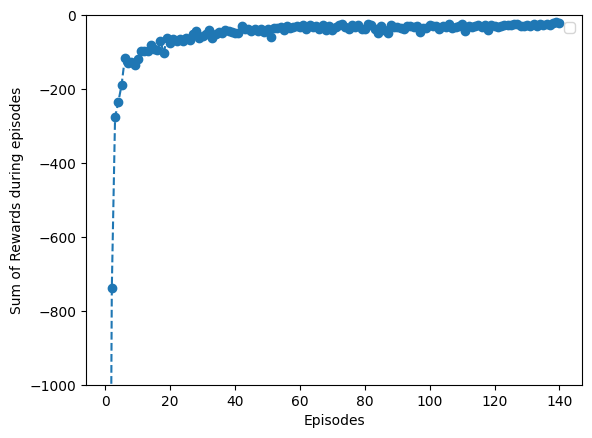

In [21]:
x = np.arange(1, 141)

plt.plot(x, rewards_sum_per_episode, marker='o', linestyle='--')
plt.xlabel('Episodes')
plt.ylabel('Sum of Rewards during episodes')
plt.ylim([-1000, 0])
plt.legend()
plt.show()